# Effect of Post-Processing on Graph Construction

This notebook supports Section **4.2. Effect of Post-Processing on Graph Construction**. It compares the same 12 builders across the sequential graph regimes **Native → ER → ER+RR**.

**Sources**:
- Native graph size is calculated from the complete `graph_nodes.jsonl` and `graph_edges.jsonl` exports.
- ER and ER+RR graphs are read from the complete GraphML workspaces selected by each variant's `workspace_locator.json`.
- The legacy `metrics.nodes` and `metrics.edges` fields in Native `final_workspace.json` are not used.

## 1. Setup and visual style

The colour palette, Computer Modern font, figure resolution, grid, and spine treatment follow `native_12_graphs_analysis.ipynb`. Outputs are written only to the `Outputs/` folder beside this notebook.

In [1]:
from __future__ import annotations

import json
import os
from pathlib import Path

start = Path.cwd().resolve()
candidates = [start, *start.parents, start / "experiment", start.parent / "experiment"]
PROJECT_ROOT = next(
    path for path in candidates
    if (path / "configs" / "experiment.yaml").is_file() and (path / "runs" / "base").is_dir()
)

NOTEBOOK_DIR = PROJECT_ROOT / "analysis" / "4.2 Effect of Post-Processing on Graph Construction"
OUTPUT_DIR = NOTEBOOK_DIR / "Outputs"
FIGURES_DIR = OUTPUT_DIR / "figures"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)
os.environ.setdefault("MPLCONFIGDIR", str(OUTPUT_DIR / ".matplotlib"))

import matplotlib.pyplot as plt
from cycler import cycler
from matplotlib.lines import Line2D
from matplotlib.patches import Patch
import networkx as nx
import numpy as np
import pandas as pd
import yaml
from IPython.display import Markdown, display

pd.set_option("display.max_columns", 100)
pd.set_option("display.max_colwidth", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

OKABE_ITO = {
    "orange": "#E69F00",
    "sky_blue": "#56B4E9",
    "bluish_green": "#009E73",
    "yellow": "#F0E442",
    "blue": "#0072B2",
    "vermillion": "#D55E00",
    "reddish_purple": "#CC79A7",
    "black": "#000000",
}
OKABE_ITO_CYCLE = [
    OKABE_ITO["blue"], OKABE_ITO["orange"], OKABE_ITO["bluish_green"],
    OKABE_ITO["vermillion"], OKABE_ITO["sky_blue"],
    OKABE_ITO["reddish_purple"], OKABE_ITO["yellow"], OKABE_ITO["black"],
]

plt.rcParams.update({
    "figure.dpi": 110,
    "savefig.dpi": 180,
    "axes.grid": True,
    "grid.alpha": 0.22,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "font.family": "cmr10",
    "font.size": 10,
    "mathtext.fontset": "cm",
    "axes.formatter.use_mathtext": True,
    "axes.prop_cycle": cycler(color=OKABE_ITO_CYCLE),
})

FAMILY_COLORS = {
    "qwen3.5": OKABE_ITO["blue"],
    "qwen3": OKABE_ITO["orange"],
    "gemma3": OKABE_ITO["bluish_green"],
}
REGIME_ORDER = ["Native", "ER", "ER+RR"]
METRICS = [
    "nodes", "edges", "density", "average_degree",
    "connected_components", "isolates", "largest_component_share",
]

print(f"PROJECT_ROOT: {PROJECT_ROOT}")
print(f"OUTPUT_DIR:   {OUTPUT_DIR}")
print(f"NetworkX: {nx.__version__}; pandas: {pd.__version__}")

PROJECT_ROOT: .
OUTPUT_DIR:   analysis/4.2 Effect of Post-Processing on Graph Construction/Outputs
NetworkX: 3.6.1; pandas: 2.3.3


## 2. Inventory of the 36 complete graphs

The experiment configuration provides the builder order and labels. Native artifacts are paired through each base manifest. ER and ER+RR artifacts are selected through the active workspace locator and a passing final-workspace gate; this avoids accidentally reading a superseded materialization attempt.

In [2]:
with (PROJECT_ROOT / "configs" / "experiment.yaml").open(encoding="utf-8") as handle:
    experiment_config = yaml.safe_load(handle)

builders = experiment_config["builders"]
builder_order = [row["key"] for row in builders]
builder_meta = {row["key"]: row for row in builders}

source_rows = []

for manifest_path in sorted((PROJECT_ROOT / "runs" / "base").glob("base_*/base_manifest.json")):
    manifest = json.loads(manifest_path.read_text(encoding="utf-8"))
    builder_key = manifest["builder_key"]
    if builder_key not in builder_meta:
        continue
    node_paths = [
        path for path in manifest_path.parent.glob("*/artifacts/graph_nodes.jsonl")
        if "backup" not in str(path).casefold() and "intermediate" not in str(path).casefold()
    ]
    pairs = [(path, path.with_name("graph_edges.jsonl")) for path in node_paths if path.with_name("graph_edges.jsonl").is_file()]
    if len(pairs) != 1:
        raise RuntimeError(f"Expected one complete Native JSONL pair for {builder_key}; found {len(pairs)}")
    nodes_path, edges_path = pairs[0]
    source_rows.append({
        "builder_key": builder_key,
        "model": builder_meta[builder_key]["display_name"],
        "family": builder_meta[builder_key]["family"],
        "regime": "Native",
        "run_id": manifest["base_run_id"],
        "format": "complete JSONL",
        "nodes_path": nodes_path,
        "edges_path": edges_path,
        "graphml_path": None,
    })

for variant_pattern, regime in [("variant_er_*", "ER"), ("variant_rr_*", "ER+RR")]:
    for locator_path in sorted((PROJECT_ROOT / "runs" / "variants").glob(f"{variant_pattern}/workspace_locator.json")):
        locator = json.loads(locator_path.read_text(encoding="utf-8"))
        builder_key = locator["builder_key"]
        gate_path = locator_path.parent / "gates" / "final_workspace.json"
        gate = json.loads(gate_path.read_text(encoding="utf-8"))
        if not all(check["passed"] for check in gate["checks"] if check["severity"] == "error"):
            raise RuntimeError(f"Final-workspace gate is not passing: {gate_path}")
        graphml_paths = list(Path(locator["workspace_dir"]).glob("*/graph_chunk_entity_relation.graphml"))
        if len(graphml_paths) != 1:
            raise RuntimeError(f"Expected one active GraphML for {locator['variant_run_id']}; found {len(graphml_paths)}")
        source_rows.append({
            "builder_key": builder_key,
            "model": builder_meta[builder_key]["display_name"],
            "family": builder_meta[builder_key]["family"],
            "regime": regime,
            "run_id": locator["variant_run_id"],
            "format": "complete GraphML",
            "nodes_path": None,
            "edges_path": None,
            "graphml_path": graphml_paths[0],
        })

inventory = pd.DataFrame(source_rows)
inventory["builder_key"] = pd.Categorical(inventory["builder_key"], builder_order, ordered=True)
inventory["regime"] = pd.Categorical(inventory["regime"], REGIME_ORDER, ordered=True)
inventory = inventory.sort_values(["builder_key", "regime"]).reset_index(drop=True)

counts = inventory.groupby("regime", observed=True)["builder_key"].nunique().reindex(REGIME_ORDER)
if counts.to_dict() != {"Native": 12, "ER": 12, "ER+RR": 12}:
    raise RuntimeError(f"Expected 12 builders in every regime; found {counts.to_dict()}")

display(
    inventory[["builder_key", "model", "regime", "format", "run_id"]]
    .style.hide(axis="index")
)
print(f"Inventory complete: {len(inventory)} graphs ({', '.join(f'{regime}={counts[regime]}' for regime in REGIME_ORDER)})")

builder_key,model,regime,format,run_id
qwen35_0_8b,Qwen3.5 0.8B,Native,complete JSONL,base_83aca3d6aa4f4a035bf5d21c
qwen35_0_8b,Qwen3.5 0.8B,ER,complete GraphML,variant_er_a622307fd50890d7409607f8
qwen35_0_8b,Qwen3.5 0.8B,ER+RR,complete GraphML,variant_rr_e28a4372fd88118216d16237
qwen35_2b,Qwen3.5 2B,Native,complete JSONL,base_6ff2fb588647938593c42b5a
qwen35_2b,Qwen3.5 2B,ER,complete GraphML,variant_er_10dd06dabafb539d38f03207
qwen35_2b,Qwen3.5 2B,ER+RR,complete GraphML,variant_rr_eddb01bdeced73ab97c84687
qwen35_4b,Qwen3.5 4B,Native,complete JSONL,base_fade67868ef8d6d4b7d790eb
qwen35_4b,Qwen3.5 4B,ER,complete GraphML,variant_er_7785257f9a3ab9e4deba47c4
qwen35_4b,Qwen3.5 4B,ER+RR,complete GraphML,variant_rr_893ede1f09002ff3e94bfb02
qwen35_9b,Qwen3.5 9B,Native,complete JSONL,base_098496a4a666032d4809338b


Inventory complete: 36 graphs (Native=12, ER=12, ER+RR=12)


## 3. Full-graph loading and descriptive metrics

Each artifact is represented as an undirected simple graph, consistent with the LightRAG graph storage used in the experiment. Connected components and isolates are therefore evaluated without edge direction. No source artifact is modified.

In [3]:
graph_rows = []
graphs = {}

for row in inventory.itertuples(index=False):
    if row.regime == "Native":
        graph = nx.Graph()
        with Path(row.nodes_path).open(encoding="utf-8") as handle:
            graph.add_nodes_from(json.loads(line)["node_id"] for line in handle if line.strip())
        with Path(row.edges_path).open(encoding="utf-8") as handle:
            graph.add_edges_from(
                (record["source"], record["target"])
                for record in (json.loads(line) for line in handle if line.strip())
            )
    else:
        graph = nx.read_graphml(row.graphml_path)
        if graph.is_directed() or graph.is_multigraph():
            graph = nx.Graph(graph)

    n = graph.number_of_nodes()
    m = graph.number_of_edges()
    components = list(nx.connected_components(graph)) if n else []
    largest_component = max((len(component) for component in components), default=0)
    graph_rows.append({
        "builder_key": str(row.builder_key),
        "model": row.model,
        "family": row.family,
        "regime": row.regime,
        "nodes": n,
        "edges": m,
        "density": nx.density(graph),
        "average_degree": 2 * m / n if n else np.nan,
        "connected_components": len(components),
        "isolates": nx.number_of_isolates(graph),
        "largest_component_share": largest_component / n if n else np.nan,
    })
    graphs[(str(row.builder_key), row.regime)] = graph

metrics = pd.DataFrame(graph_rows)
metrics["builder_key"] = pd.Categorical(metrics["builder_key"], builder_order, ordered=True)
metrics["regime"] = pd.Categorical(metrics["regime"], REGIME_ORDER, ordered=True)
metrics = metrics.sort_values(["builder_key", "regime"]).reset_index(drop=True)
metrics.to_csv(OUTPUT_DIR / "graph_metrics_by_builder_and_regime.csv", index=False)

print(f"Loaded {len(graphs)} complete graphs")

Loaded 36 complete graphs


## 4. Absolute graph structure by builder

The complete builder-level table is retained because relative changes can obscure the underlying graph scale. Every row represents one builder and one regime; the source CSV is saved as `graph_metrics_by_builder_and_regime.csv`.

In [4]:
display(
    metrics.style
    .hide(axis="index")
    .format({
        "nodes": "{:,}", "edges": "{:,}", "density": "{:.6f}",
        "average_degree": "{:.2f}", "connected_components": "{:,}",
        "isolates": "{:,}", "largest_component_share": "{:.1%}",
    })
    .background_gradient(subset=["nodes", "edges", "average_degree", "largest_component_share"], cmap="YlGnBu")
)

builder_key,model,family,regime,nodes,edges,density,average_degree,connected_components,isolates,largest_component_share
qwen35_0_8b,Qwen3.5 0.8B,qwen3.5,Native,"3,029","2,054",0.000448,1.36,"1,226",956,25.6%
qwen35_0_8b,Qwen3.5 0.8B,qwen3.5,ER,"2,995","2,045",0.000456,1.37,"1,204",939,25.8%
qwen35_0_8b,Qwen3.5 0.8B,qwen3.5,ER+RR,"2,995","2,205",0.000492,1.47,"1,106",845,27.5%
qwen35_2b,Qwen3.5 2B,qwen3.5,Native,"5,825","4,690",0.000276,1.61,"1,826","1,154",43.4%
qwen35_2b,Qwen3.5 2B,qwen3.5,ER,"5,750","4,677",0.000283,1.63,"1,775","1,123",44.2%
qwen35_2b,Qwen3.5 2B,qwen3.5,ER+RR,"5,750","4,755",0.000288,1.65,"1,725","1,082",45.1%
qwen35_4b,Qwen3.5 4B,qwen3.5,Native,"7,256","6,263",0.000238,1.73,"2,020","1,321",51.9%
qwen35_4b,Qwen3.5 4B,qwen3.5,ER,"7,153","6,239",0.000244,1.74,"1,954","1,289",53.1%
qwen35_4b,Qwen3.5 4B,qwen3.5,ER+RR,"7,153","6,299",0.000246,1.76,"1,922","1,265",53.7%
qwen35_9b,Qwen3.5 9B,qwen3.5,Native,"6,383","6,085",0.000299,1.91,"1,458",979,60.4%


## 5. Builder-matched contrasts and compact descriptive summary

All differences are calculated within the same builder. Absolute differences are retained in `paired_builder_changes.csv`. For cross-metric comparison, nodes, edges, density, average degree, connected components, and isolates are also expressed as percentage changes from the left-hand regime; largest-component share is expressed as a percentage-point change.

The compact table reports the median and full observed range across the 12 builders. The final notation gives the number of builders with a decrease, no change, and an increase. These are descriptive summaries, not inferential estimates.

In [5]:
contrast_plan = [
    ("ER−Native", "Native", "ER"),
    ("ER+RR−ER", "ER", "ER+RR"),
    ("ER+RR−Native", "Native", "ER+RR"),
]

change_rows = []
relative_rows = []

for builder_key in builder_order:
    group = metrics.loc[metrics["builder_key"] == builder_key].set_index("regime")
    for contrast, left, right in contrast_plan:
        absolute = {
            "builder_key": builder_key,
            "model": group.loc[left, "model"],
            "family": group.loc[left, "family"],
            "contrast": contrast,
        }
        relative = absolute.copy()
        for metric in METRICS:
            left_value = group.loc[left, metric]
            right_value = group.loc[right, metric]
            absolute[metric] = right_value - left_value
            if metric == "largest_component_share":
                relative[metric] = 100 * (right_value - left_value)  # percentage points
            else:
                relative[metric] = 100 * (right_value - left_value) / left_value
        change_rows.append(absolute)
        relative_rows.append(relative)

paired_changes = pd.DataFrame(change_rows)
relative_changes = pd.DataFrame(relative_rows)

contrast_order = [item[0] for item in contrast_plan]
for frame in (paired_changes, relative_changes):
    frame["builder_key"] = pd.Categorical(frame["builder_key"], builder_order, ordered=True)
    frame["contrast"] = pd.Categorical(frame["contrast"], contrast_order, ordered=True)
    frame.sort_values(["builder_key", "contrast"], inplace=True)
    frame.reset_index(drop=True, inplace=True)

paired_changes.to_csv(OUTPUT_DIR / "paired_builder_changes.csv", index=False)
relative_changes.to_csv(OUTPUT_DIR / "paired_builder_relative_changes.csv", index=False)

summary_rows = []
for contrast in contrast_order:
    subset = relative_changes.loc[relative_changes["contrast"] == contrast]
    for metric in METRICS:
        values = subset[metric]
        summary_rows.append({
            "contrast": contrast,
            "metric": metric,
            "unit": "pp" if metric == "largest_component_share" else "%",
            "median": values.median(),
            "minimum": values.min(),
            "maximum": values.max(),
            "decrease": int(values.lt(0).sum()),
            "unchanged": int(values.eq(0).sum()),
            "increase": int(values.gt(0).sum()),
        })

paired_summary = pd.DataFrame(summary_rows)
paired_summary.to_csv(OUTPUT_DIR / "paired_change_summary.csv", index=False)

metric_labels = {
    "nodes": "Nodes",
    "edges": "Edges",
    "density": "Density",
    "average_degree": "Average degree",
    "connected_components": "Components",
    "isolates": "Isolates",
    "largest_component_share": "Largest component",
}

summary_matrix = pd.DataFrame(index=contrast_order, columns=[metric_labels[m] for m in METRICS])
for row in paired_summary.itertuples(index=False):
    direction = f"{row.decrease}↓ / {row.unchanged}= / {row.increase}↑"
    summary_matrix.loc[row.contrast, metric_labels[row.metric]] = (
        f"{row.median:+.1f}{row.unit} "
        f"[{row.minimum:+.1f}, {row.maximum:+.1f}]; {direction}"
    )

display(summary_matrix.style.set_caption(
    "Median [minimum, maximum] paired change; builders decreasing / unchanged / increasing"
))
print(f"Saved {len(paired_changes)} absolute and {len(relative_changes)} normalised builder-matched contrasts")

,Nodes,Edges,Density,Average degree,Components,Isolates,Largest component
ER−Native,"-1.5% [-6.7, -1.1]; 12↓ / 0= / 0↑","-0.4% [-0.7, -0.1]; 12↓ / 0= / 0↑","+2.5% [+1.8, +14.3]; 0↓ / 0= / 12↑","+1.0% [+0.7, +6.6]; 0↓ / 0= / 12↑","-3.1% [-7.6, -1.8]; 12↓ / 0= / 0↑","-2.7% [-7.7, -1.8]; 12↓ / 0= / 0↑","+0.7pp [+0.2, +1.6]; 0↓ / 0= / 12↑"
ER+RR−ER,"+0.0% [+0.0, +0.0]; 0↓ / 12= / 0↑","+2.4% [+0.6, +177.7]; 0↓ / 0= / 12↑","+2.4% [+0.6, +177.7]; 0↓ / 0= / 12↑","+2.4% [+0.6, +177.7]; 0↓ / 0= / 12↑","-3.0% [-30.4, -1.2]; 12↓ / 0= / 0↑","-4.0% [-47.7, -1.6]; 12↓ / 0= / 0↑","+1.3pp [+0.3, +5.0]; 0↓ / 0= / 12↑"
ER+RR−Native,"-1.5% [-6.7, -1.1]; 12↓ / 0= / 0↑","+1.8% [+0.2, +175.9]; 0↓ / 0= / 12↑","+5.6% [+2.8, +190.0]; 0↓ / 0= / 12↑","+3.4% [+1.5, +182.9]; 0↓ / 0= / 12↑","-7.2% [-32.3, -3.8]; 12↓ / 0= / 0↑","-7.9% [-48.8, -3.8]; 12↓ / 0= / 0↑","+2.1pp [+1.0, +5.7]; 0↓ / 0= / 12↑"


Saved 36 absolute and 36 normalised builder-matched contrasts


## 6. Graph size and net Native-to-ER+RR change

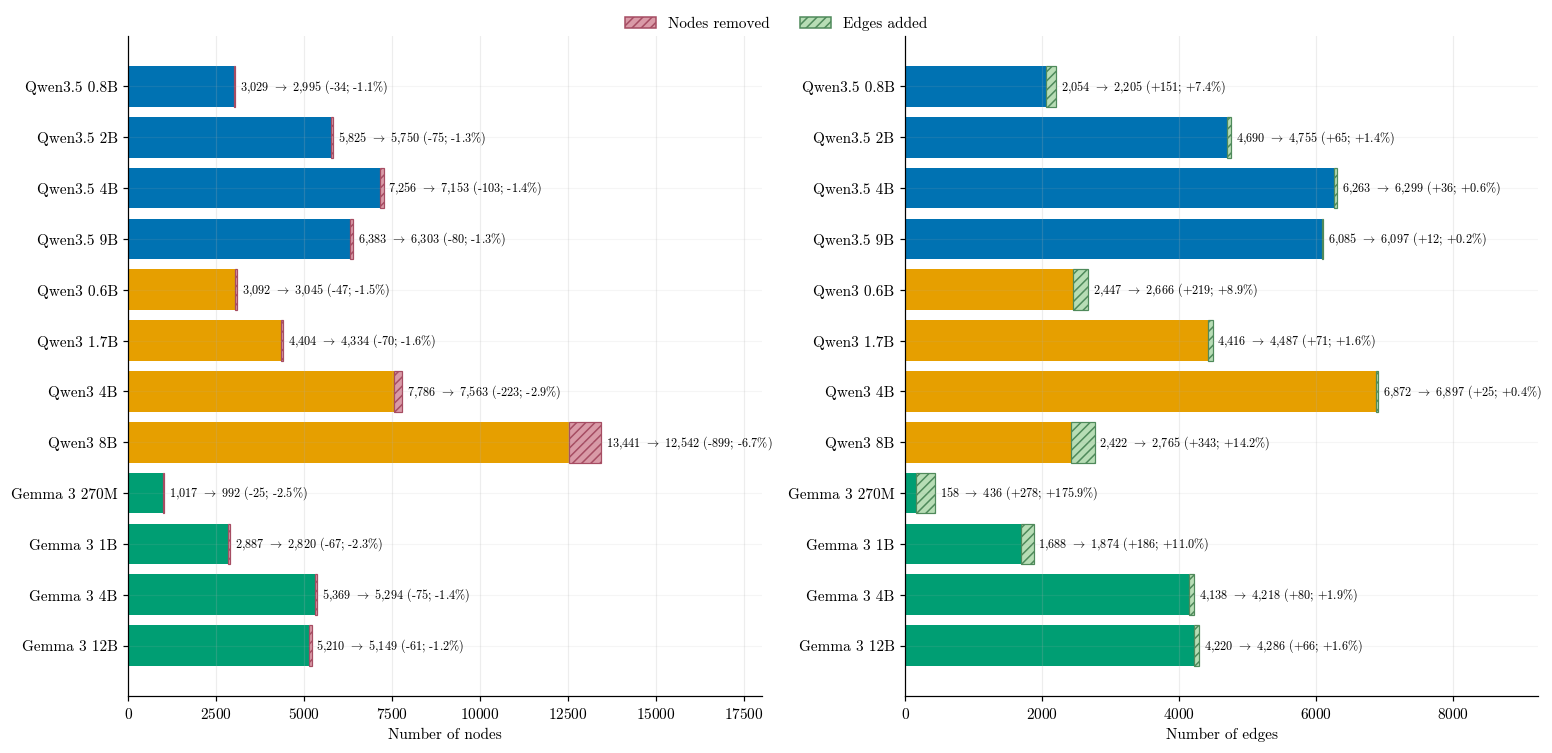

In [6]:
regime_colors = {
    "Native": OKABE_ITO["black"],
    "ER": OKABE_ITO["blue"],
    "ER+RR": OKABE_ITO["vermillion"],
}
regime_markers = {"Native": "o", "ER": "s", "ER+RR": "D"}
regime_offsets = {"Native": -0.18, "ER": 0.0, "ER+RR": 0.18}

size_by_regime = (
    metrics.pivot(index="builder_key", columns="regime", values=["nodes", "edges"])
    .reindex(builder_order)
)
model_labels = [builder_meta[key]["display_name"] for key in builder_order]
family_colors = [FAMILY_COLORS[builder_meta[key]["family"]] for key in builder_order]
y = np.arange(len(builder_order))

native_nodes = size_by_regime[("nodes", "Native")].to_numpy()
final_nodes = size_by_regime[("nodes", "ER+RR")].to_numpy()
removed_nodes = native_nodes - final_nodes
native_edges = size_by_regime[("edges", "Native")].to_numpy()
final_edges = size_by_regime[("edges", "ER+RR")].to_numpy()
added_edges = final_edges - native_edges

REMOVED_COLOR = "#D99AA7"
REMOVED_EDGE = "#A64D63"
ADDED_COLOR = "#B7DDB5"
ADDED_EDGE = "#4F8A5B"

fig, axes = plt.subplots(1, 2, figsize=(14, 6.5), constrained_layout=True)

# Nodes: the family-coloured bar ends at ER+RR; the hatched tail shows what Native lost.
axes[0].barh(y, final_nodes, color=family_colors)
axes[0].barh(
    y, removed_nodes, left=final_nodes, color=REMOVED_COLOR,
    edgecolor=REMOVED_EDGE, hatch="////", linewidth=0.8,
)

# Edges: the family-coloured bar is Native; the hatched extension is the ER+RR gain.
axes[1].barh(y, native_edges, color=family_colors)
axes[1].barh(
    y, added_edges, left=native_edges, color=ADDED_COLOR,
    edgecolor=ADDED_EDGE, hatch="////", linewidth=0.8,
)

panel_values = [
    (native_nodes, final_nodes, removed_nodes, "Number of nodes"),
    (native_edges, final_edges, added_edges, "Number of edges"),
]
for ax, (native, final, change, xlabel) in zip(axes, panel_values):
    endpoints = np.maximum(native, final)
    padding = endpoints.max() * 0.01
    for row_y, native_value, final_value, endpoint in zip(y, native, final, endpoints):
        signed_delta = final_value - native_value
        change_pct = 100 * signed_delta / native_value
        ax.text(
            endpoint + padding, row_y,
            (
                f"{native_value:,.0f} $\\rightarrow$ {final_value:,.0f} "
                f"({signed_delta:+,.0f}; {change_pct:+.1f}%)"
            ),
            va="center", ha="left", fontsize=8,
        )
    ax.set_yticks(y, model_labels)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, endpoints.max() * 1.34)
    ax.grid(axis="y", alpha=0.12)

fig.legend(
    handles=[
        Patch(facecolor=REMOVED_COLOR, edgecolor=REMOVED_EDGE, hatch="////", label="Nodes removed"),
        Patch(facecolor=ADDED_COLOR, edgecolor=ADDED_EDGE, hatch="////", label="Edges added"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, 1.04), ncol=2, frameon=False,
)

fig.savefig(FIGURES_DIR / "01_graph_size_by_builder.png", bbox_inches="tight")
plt.show()

**Figure 1. Absolute graph size and paired net change from Native to ER+RR.** Family colours and horizontal bars follow the Native graph-size figure. The pink hatched segment marks nodes removed from Native; the light-green hatched segment marks edges added beyond Native. Labels report `Native → ER+RR (paired change)`. Node counts decrease and edge counts increase for all 12 builders; these are descriptive structural changes.

## 7. Structural metrics and net Native-to-ER+RR change

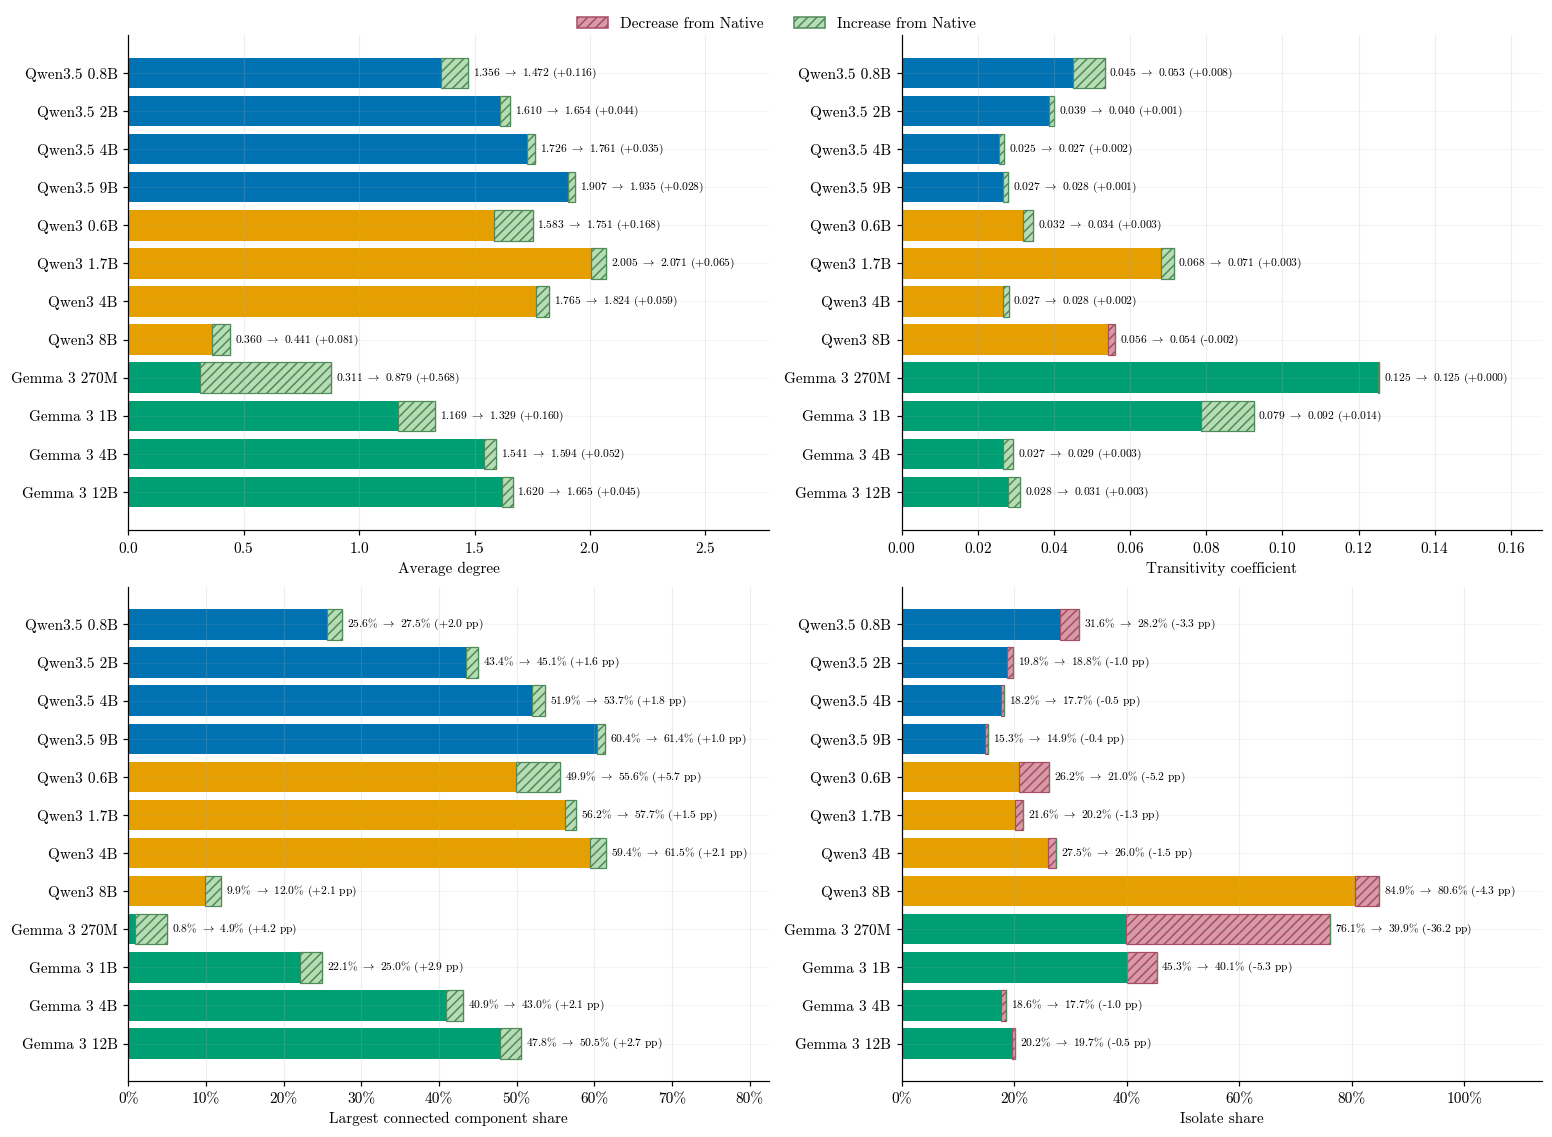

In [7]:
structural_rows = []
for builder_key in builder_order:
    for regime in ["Native", "ER+RR"]:
        row = metrics.loc[
            (metrics["builder_key"] == builder_key) & (metrics["regime"] == regime)
        ].iloc[0]
        structural_rows.append({
            "builder_key": builder_key,
            "regime": regime,
            "average_degree": row["average_degree"],
            "transitivity": nx.transitivity(graphs[(builder_key, regime)]),
            "largest_component_share": row["largest_component_share"],
            "isolate_share": row["isolates"] / row["nodes"],
        })

structural = pd.DataFrame(structural_rows)
structural_by_regime = structural.pivot(
    index="builder_key", columns="regime",
    values=["average_degree", "transitivity", "largest_component_share", "isolate_share"],
).reindex(builder_order)

structural_panels = [
    ("average_degree", "Average degree", False),
    ("transitivity", "Transitivity coefficient", False),
    ("largest_component_share", "Largest connected component share", True),
    ("isolate_share", "Isolate share", True),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10), constrained_layout=True)
for ax, (metric, xlabel, is_share) in zip(axes.flat, structural_panels):
    native = structural_by_regime[(metric, "Native")].to_numpy()
    final = structural_by_regime[(metric, "ER+RR")].to_numpy()
    decrease = np.maximum(native - final, 0)
    increase = np.maximum(final - native, 0)
    endpoints = np.maximum(native, final)

    ax.barh(y, native, color=family_colors)
    ax.barh(
        y, decrease, left=final, color=REMOVED_COLOR,
        edgecolor=REMOVED_EDGE, hatch="////", linewidth=0.8,
    )
    ax.barh(
        y, increase, left=native, color=ADDED_COLOR,
        edgecolor=ADDED_EDGE, hatch="////", linewidth=0.8,
    )

    padding = endpoints.max() * 0.01
    for row_y, native_value, final_value, endpoint in zip(y, native, final, endpoints):
        delta = final_value - native_value
        if is_share:
            label = (
                f"{native_value:.1%} $\\rightarrow$ {final_value:.1%} "
                f"({delta * 100:+.1f} pp)"
            )
        else:
            label = f"{native_value:.3f} $\\rightarrow$ {final_value:.3f} ({delta:+.3f})"
        ax.text(endpoint + padding, row_y, label, va="center", ha="left", fontsize=7.5)

    ax.set_yticks(y, model_labels)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.set_xlim(0, max(endpoints.max() * 1.34, 1e-9))
    ax.grid(axis="y", alpha=0.12)
    if is_share:
        ax.xaxis.set_major_formatter(plt.matplotlib.ticker.PercentFormatter(1.0))

fig.legend(
    handles=[
        Patch(facecolor=REMOVED_COLOR, edgecolor=REMOVED_EDGE, hatch="////", label="Decrease from Native"),
        Patch(facecolor=ADDED_COLOR, edgecolor=ADDED_EDGE, hatch="////", label="Increase from Native"),
    ],
    loc="upper center", bbox_to_anchor=(0.5, 1.025), ncol=2, frameon=False,
)

fig.savefig(FIGURES_DIR / "02_connectivity_by_builder.png", bbox_inches="tight")
plt.show()

**Figure 2. Structural metrics and paired net change from Native to ER+RR.** The 2 × 2 layout, family colours, and horizontal bars follow the Native structural-metrics figure. Pink hatched segments mark decreases from Native; light-green hatched segments mark increases. Labels report `Native → ER+RR (paired change)`; share changes are expressed in percentage points. These are descriptive structural changes.

## 8. Stage decomposition of the cumulative change

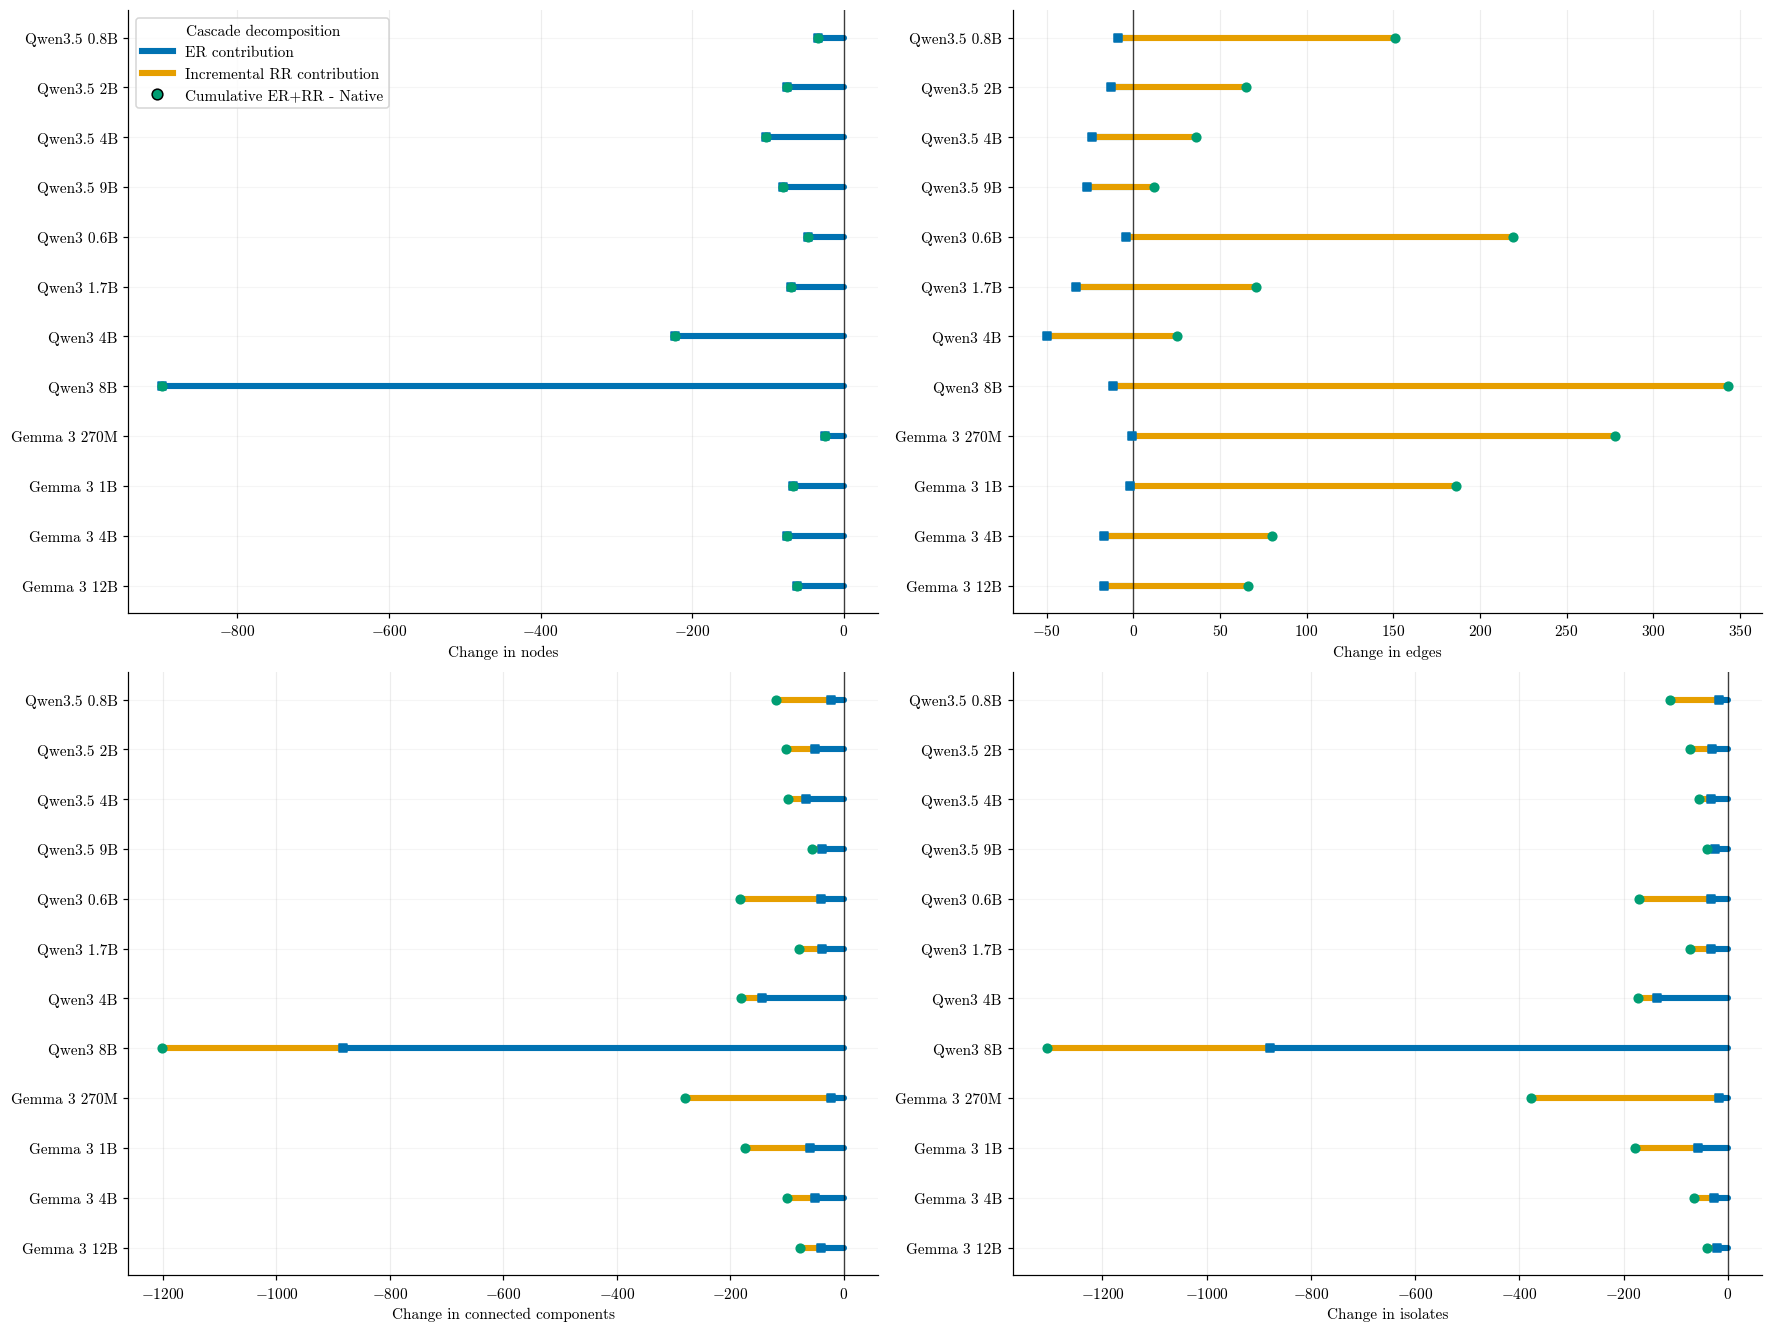

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12), constrained_layout=True)
decomposition_panels = [
    ("nodes", "Change in nodes"),
    ("edges", "Change in edges"),
    ("connected_components", "Change in connected components"),
    ("isolates", "Change in isolates"),
]

for ax, (metric, xlabel) in zip(axes.flat, decomposition_panels):
    er_change = (
        paired_changes.loc[paired_changes["contrast"] == "ER−Native"]
        .set_index("builder_key").reindex(builder_order)[metric]
    )
    rr_change = (
        paired_changes.loc[paired_changes["contrast"] == "ER+RR−ER"]
        .set_index("builder_key").reindex(builder_order)[metric]
    )
    total_change = er_change + rr_change

    for position, builder_key in enumerate(builder_order):
        er_value = er_change.loc[builder_key]
        total_value = total_change.loc[builder_key]
        ax.plot([0, er_value], [position, position], color=OKABE_ITO["blue"],
                linewidth=4.0, solid_capstyle="round")
        ax.plot([er_value, total_value], [position, position], color=OKABE_ITO["orange"],
                linewidth=4.0, solid_capstyle="round")
        ax.scatter(er_value, position, color=OKABE_ITO["blue"], marker="s", s=28, zorder=3)
        ax.scatter(total_value, position, color=OKABE_ITO["bluish_green"], marker="o", s=32, zorder=4)

    ax.axvline(0, color=OKABE_ITO["black"], linewidth=0.9, alpha=0.75)
    ax.set_yticks(y, model_labels)
    ax.invert_yaxis()
    ax.set_xlabel(xlabel)
    ax.grid(axis="y", alpha=0.12)

decomposition_legend = [
    Line2D([0], [0], color=OKABE_ITO["blue"], linewidth=4, label="ER contribution"),
    Line2D([0], [0], color=OKABE_ITO["orange"], linewidth=4, label="Incremental RR contribution"),
    Line2D([0], [0], marker="o", color="none", markerfacecolor=OKABE_ITO["bluish_green"],
           markersize=7, label="Cumulative ER+RR - Native"),
]
axes[0, 0].legend(handles=decomposition_legend, title="Cascade decomposition", loc="best")
fig.savefig(FIGURES_DIR / "03_stage_decomposition.png", bbox_inches="tight")
plt.show()

**Figure 3. Additive decomposition of the cumulative structural difference.** Each row begins at zero. The blue segment is ER−Native; the orange segment continues from that endpoint by ER+RR−ER; the green marker is the cumulative ER+RR−Native result. Node contraction is entirely introduced by ER. For edges, the incremental RR addition more than offsets the small ER reduction for every builder. Both stages contribute to lower component and isolate counts.

## 9. Model size versus graph size before and after post-processing

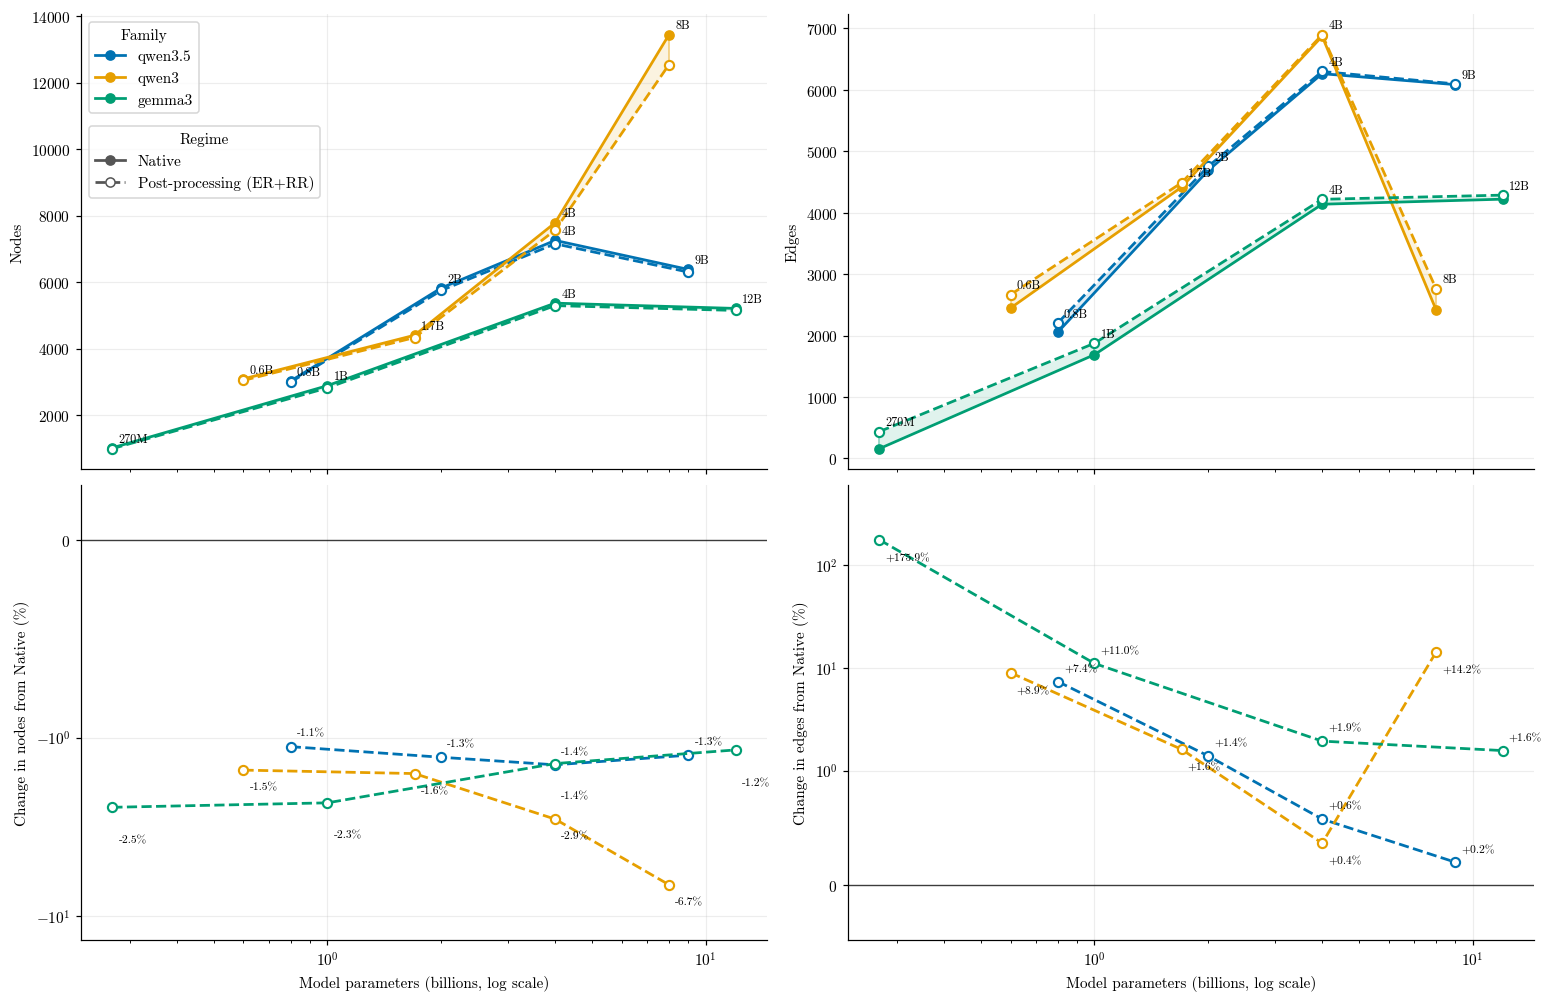

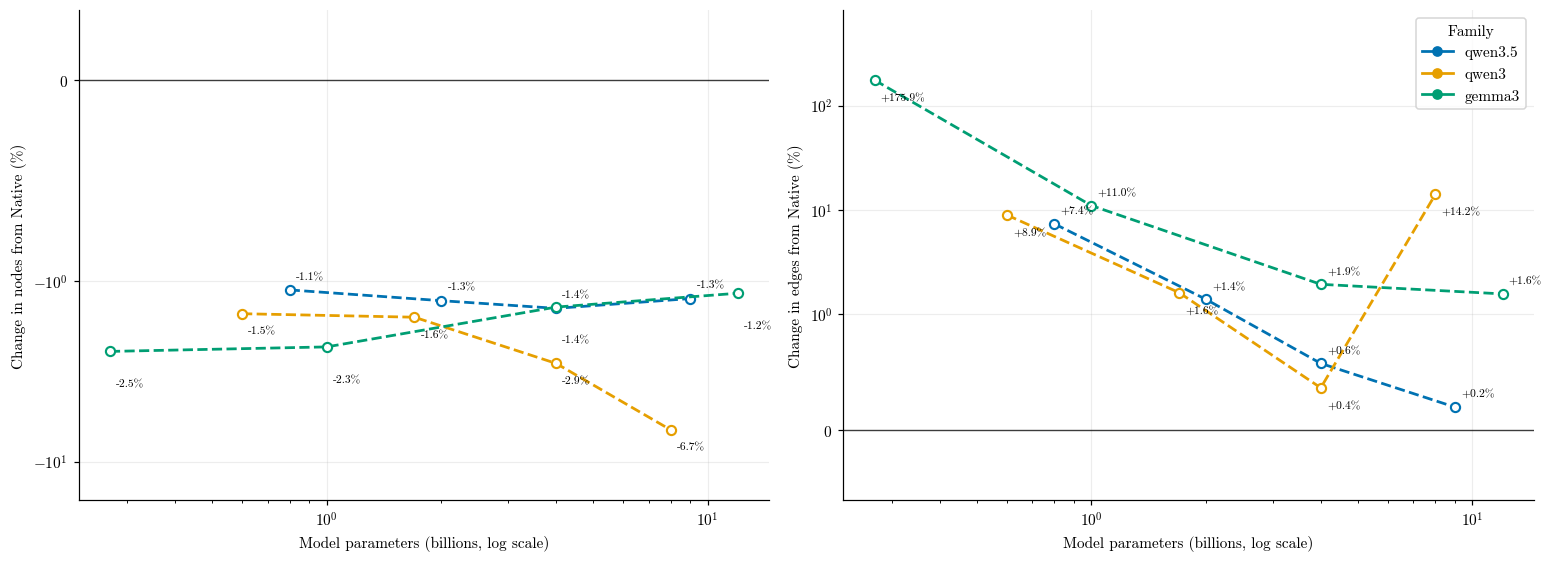

In [9]:
model_size_rows = []
for builder_key in builder_order:
    model_name = builder_meta[builder_key]["display_name"]
    size_token = model_name.split()[-1].upper()
    parameters_b = float(size_token[:-1])
    if size_token.endswith("M"):
        parameters_b /= 1000.0
    model_size_rows.append({
        "builder_key": builder_key,
        "model": model_name,
        "family": builder_meta[builder_key]["family"],
        "parameters_b": parameters_b,
        "short_label": (
            model_name.replace("Qwen3.5 ", "")
            .replace("Qwen3 ", "")
            .replace("Gemma 3 ", "")
        ),
    })

model_sizes = pd.DataFrame(model_size_rows)
fig, axes = plt.subplots(2, 2, figsize=(14, 9), sharex="col", constrained_layout=True)

for column, (metric, ylabel) in enumerate(zip(["nodes", "edges"], ["Nodes", "Edges"])):
    absolute_ax = axes[0, column]
    change_ax = axes[1, column]
    for family in ["qwen3.5", "qwen3", "gemma3"]:
        family_models = (
            model_sizes.loc[model_sizes["family"] == family]
            .sort_values("parameters_b")
        )
        keys = family_models["builder_key"].tolist()
        native = (
            metrics.loc[metrics["regime"] == "Native"]
            .set_index("builder_key").reindex(keys)[metric].to_numpy()
        )
        final = (
            metrics.loc[metrics["regime"] == "ER+RR"]
            .set_index("builder_key").reindex(keys)[metric].to_numpy()
        )
        x = family_models["parameters_b"].to_numpy()
        color = FAMILY_COLORS[family]

        absolute_ax.fill_between(x, native, final, color=color, alpha=0.12, linewidth=0)
        absolute_ax.vlines(
            x, np.minimum(native, final), np.maximum(native, final),
            color=color, alpha=0.5, linewidth=1.0,
        )
        absolute_ax.plot(x, native, marker="o", linewidth=1.8, linestyle="-", color=color)
        absolute_ax.plot(
            x, final, marker="o", linewidth=1.8, linestyle="--", color=color,
            markerfacecolor="white", markeredgecolor=color, markeredgewidth=1.4,
        )
        for row, native_value, final_value in zip(family_models.itertuples(index=False), native, final):
            absolute_ax.annotate(
                row.short_label, (row.parameters_b, max(native_value, final_value)),
                xytext=(4, 4), textcoords="offset points", fontsize=8,
            )

        change_pct = 100 * (final - native) / native
        change_ax.plot(
            x, change_pct, marker="o", linewidth=1.8, linestyle="--", color=color,
            markerfacecolor="white", markeredgecolor=color, markeredgewidth=1.4,
        )
        if metric == "nodes":
            label_offset_y = {"qwen3.5": 7, "qwen3": -13, "gemma3": -23}[family]
        else:
            label_offset_y = {"qwen3.5": 7, "qwen3": -13, "gemma3": 7}[family]
        for x_value, delta in zip(x, change_pct):
            point_offset_y = -13 if delta > 100 else label_offset_y
            change_ax.annotate(
                f"{delta:+.1f}%", (x_value, delta),
                xytext=(4, point_offset_y),
                textcoords="offset points", fontsize=7.5,
            )

    absolute_ax.set_xscale("log")
    absolute_ax.set_ylabel(ylabel)
    change_ax.set_xscale("log")
    change_ax.set_yscale("symlog", linthresh=1.0, linscale=1.0)
    change_ax.axhline(0, color=OKABE_ITO["black"], linewidth=0.9, alpha=0.75)
    change_ax.margins(y=0.16)
    change_ax.set_xlabel("Model parameters (billions, log scale)")
    change_ax.set_ylabel(f"Change in {metric} from Native (%)")

family_handles = [
    Line2D([0], [0], color=FAMILY_COLORS[family], marker="o", linewidth=1.8, label=family)
    for family in ["qwen3.5", "qwen3", "gemma3"]
]
regime_handles = [
    Line2D([0], [0], color="#555555", marker="o", linewidth=1.8, linestyle="-", label="Native"),
    Line2D(
        [0], [0], color="#555555", marker="o", markerfacecolor="white",
        linewidth=1.8, linestyle="--", label="Post-processing (ER+RR)",
    ),
]
family_legend = axes[0, 0].legend(
    handles=family_handles, title="Family", loc="upper left",
)
axes[0, 0].add_artist(family_legend)
axes[0, 0].legend(
    handles=regime_handles, title="Regime", loc="upper left",
    bbox_to_anchor=(0.0, 0.77),
)

fig.savefig(FIGURES_DIR / "04_model_size_vs_graph_size_post_processing.png", bbox_inches="tight")
plt.show()

# Standalone export of the lower row for a clearer view of relative changes.
change_fig, change_axes = plt.subplots(1, 2, figsize=(14, 5), constrained_layout=True)

for ax, metric in zip(change_axes, ["nodes", "edges"]):
    for family in ["qwen3.5", "qwen3", "gemma3"]:
        family_models = (
            model_sizes.loc[model_sizes["family"] == family]
            .sort_values("parameters_b")
        )
        keys = family_models["builder_key"].tolist()
        native = (
            metrics.loc[metrics["regime"] == "Native"]
            .set_index("builder_key").reindex(keys)[metric].to_numpy()
        )
        final = (
            metrics.loc[metrics["regime"] == "ER+RR"]
            .set_index("builder_key").reindex(keys)[metric].to_numpy()
        )
        x = family_models["parameters_b"].to_numpy()
        change_pct = 100 * (final - native) / native
        color = FAMILY_COLORS[family]

        ax.plot(
            x, change_pct, marker="o", linewidth=1.8, linestyle="--", color=color,
            markerfacecolor="white", markeredgecolor=color, markeredgewidth=1.4,
        )
        if metric == "nodes":
            label_offset_y = {"qwen3.5": 7, "qwen3": -13, "gemma3": -23}[family]
        else:
            label_offset_y = {"qwen3.5": 7, "qwen3": -13, "gemma3": 7}[family]
        for x_value, delta in zip(x, change_pct):
            point_offset_y = -13 if delta > 100 else label_offset_y
            ax.annotate(
                f"{delta:+.1f}%", (x_value, delta),
                xytext=(4, point_offset_y), textcoords="offset points", fontsize=7.5,
            )

    ax.set_xscale("log")
    ax.set_yscale("symlog", linthresh=1.0, linscale=1.0)
    ax.axhline(0, color=OKABE_ITO["black"], linewidth=0.9, alpha=0.75)
    ax.margins(y=0.20)
    ax.set_xlabel("Model parameters (billions, log scale)")
    ax.set_ylabel(f"Change in {metric} from Native (%)")

change_axes[1].legend(handles=family_handles, title="Family", loc="upper right")
change_fig.savefig(
    FIGURES_DIR / "05_model_size_vs_post_processing_change.png",
    bbox_inches="tight",
)
plt.show()

**Figure 4. Model size versus graph size before and after post-processing.** In the upper row, solid lines show Native graphs and dashed lines of the same family colour show the cumulative ER+RR result; translucent bands and vertical connectors expose the paired gap. The lower row reports the paired percentage change on a symmetric-logarithmic scale, preserving visibility of both small changes and the large Gemma 3 270M edge increase. The edge trajectory shows partial compensation for the edge-poor Qwen3 8B and Gemma 3 270M graphs, but the family-specific discontinuities remain. Node trajectories are mostly shifted downward without a general smoothing effect, although the pronounced Qwen3 8B node peak is reduced. The comparison is descriptive and does not imply that model size causes graph size or that structural compensation improves downstream quality.

**Figure 5. Relative graph-size change after post-processing by model size.** This standalone view reproduces the lower row of Figure 4, showing the paired ER+RR change from Native for nodes and edges.

## 10. Descriptive interpretation

Three regularities hold across all 12 builders. First, ER reduces the node set (median −1.47%; range −6.69% to −1.12%) and produces a smaller reduction in edges (median −0.42%). Because nodes decline more than edges, density and average degree increase even before RR. Qwen3 8B shows the largest ER contraction: −899 nodes and −883 connected components, corresponding to −6.69% and −7.64% of its Native values.

Second, ER+RR leaves the ER node count unchanged and adds edges for every builder. The incremental edge increase is heterogeneous: the median is +2.36%, while the range extends from +0.64% to +177.71%. The extreme relative change belongs to Gemma 3 270M and should be read together with its small ER baseline (157 edges); it is not evidence of superior semantic recovery.

Third, the cumulative ER+RR graph has fewer nodes but more edges than Native for every builder. Across builders, the median cumulative changes are −1.47% in nodes, +1.77% in edges, −7.18% in connected components, −7.86% in isolates, and +2.12 percentage points in largest-component share. Thus, the direction of the topology shift is highly consistent, while its magnitude is builder-dependent.

These results describe graph construction only. They do not establish that entity merges are correct, that recovered relations are supported, or that retrieval and answer quality improve. Those questions require the experiment's separate ER, RR, retrieval, and answering evaluations.